In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.utils import resample
from sklearn.base import clone

In [23]:
mega = pd.read_csv("data/mega.csv")
mega

,Season,Team,G,Age,W,L,PW,PL,Pace,FTr,3PAr,OFF_eFG%,DEF_eFG%,OFF_TOV%,DEF_TOV%,ORB%,DRB%,OFF_FT/FGA,DEF_FT/FGA,pyth_diff
0,2014,Los Angeles Clippers,82,28.1,57,25.0,59,23,95.9,0.353,0.291,0.526,0.484,12.7,13.8,25.0,72.5,0.258,0.222,-2
1,2014,Houston Rockets,82,25.4,54,28.0,53,29,96.3,0.386,0.330,0.531,0.489,14.6,12.5,27.4,74.1,0.275,0.193,1
2,2014,Minnesota Timberwolves,82,26.3,40,42.0,48,34,97.3,0.321,0.245,0.486,0.518,12.2,14.8,27.4,74.4,0.249,0.177,-8
3,2014,Portland Trail Blazers,82,25.8,54,28.0,52,30,94.9,0.270,0.290,0.504,0.488,12.4,10.9,28.0,74.7,0.220,0.194,2
4,2014,Oklahoma City Thunder,82,26.2,59,23.0,58,24,95.4,0.303,0.271,0.520,0.488,14.0,13.9,26.5,75.6,0.244,0.221,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385,2026,Phoenix Suns,82,26.8,45,37.0,45,37,97.2,0.225,0.453,0.537,0.541,12.8,14.5,28.9,71.9,0.176,0.217,0
386,2026,Indiana Pacers,82,26.1,19,63.0,23,59,101.0,0.252,0.422,0.533,0.556,12.8,11.7,21.7,74.1,0.196,0.218,-4
387,2026,Sacramento Kings,82,28.3,22,60.0,19,63,99.2,0.256,0.339,0.525,0.572,12.6,12.3,25.9,73.5,0.198,0.216,3
388,2026,Milwaukee Bucks,82,27.1,32,50.0,26,56,97.6,0.223,0.457,0.565,0.558,13.9,11.7,21.1,74.1,0.163,0.215,6


In [24]:
print(mega[['FTr', 'OFF_FT/FGA']].corr())


                 FTr  OFF_FT/FGA
FTr         1.000000    0.929897
OFF_FT/FGA  0.929897    1.000000


In [25]:
mega = mega.drop(columns=['OFF_FT/FGA'])

# Rename for consistency other Four Factor names
mega = mega.rename(columns={'FTr': 'OFF_FT/FGA'})
mega['Season'] = mega['Season'].astype(int)
mega['L'] = mega['L'].astype(int)

mega['Team'] = mega['Team'].replace({
    'Charlotte Bobcats': 'Charlotte Hornets'
})


In [26]:
features = [
    'G', 'Age', 'Pace', '3PAr',
    'OFF_eFG%', 'DEF_eFG%',
    'OFF_TOV%', 'DEF_TOV%',
    'ORB%', 'DRB%',
    'OFF_FT/FGA', 'DEF_FT/FGA',
    'pyth_diff'
]

# Drop rows with any nulls in features before VIF
vif_data = mega[features].dropna()

# Add constant for VIF calculation
X = add_constant(vif_data)

# Compute VIF for each feature
vif_df = pd.DataFrame({
    'Feature': features,
    'VIF': [variance_inflation_factor(X.values, i+1) 
            for i in range(len(features))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df)


       Feature       VIF
0         3PAr  2.556793
1     OFF_eFG%  2.543089
2         Pace  1.965293
3     DEF_eFG%  1.817853
4          Age  1.683338
5         DRB%  1.417934
6   DEF_FT/FGA  1.411452
7     DEF_TOV%  1.351358
8     OFF_TOV%  1.278814
9            G  1.262741
10  OFF_FT/FGA  1.237403
11        ORB%  1.234909
12   pyth_diff  1.078780


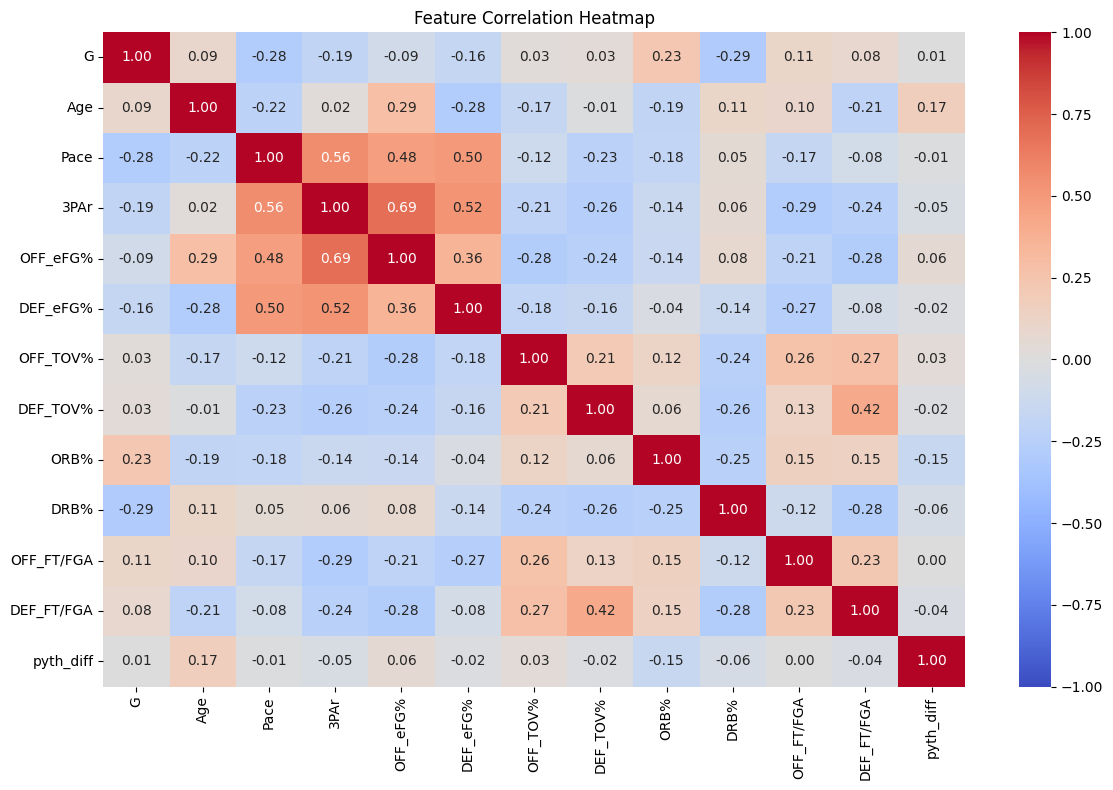

In [27]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    mega[features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [28]:
print("=== DATASET SHAPE ===")
print(f"Rows: {mega.shape[0]}")
print(f"Columns: {mega.shape[1]}")
print(f"Seasons: {mega['Season'].min()} - {mega['Season'].max()}")
print(f"Teams per season:\n{mega.groupby('Season').size()}")

print("\n=== MISSING VALUES ===")
print(mega.isnull().sum())

print("\n=== DATA TYPES ===")
print(mega.dtypes)

print("\n=== SUMMARY STATISTICS ===")
print(mega.describe().round(2))

print("\n=== WIN DISTRIBUTION ===")
print(f"Mean wins:   {mega['W'].mean():.1f}")
print(f"Std wins:    {mega['W'].std():.1f}")
print(f"Min wins:    {mega['W'].min()}")
print(f"Max wins:    {mega['W'].max()}")
print(f"Median wins: {mega['W'].median():.1f}")

print("\n=== PYTH DIFF DISTRIBUTION ===")
print(f"Mean:  {mega['pyth_diff'].mean():.2f}")
print(f"Std:   {mega['pyth_diff'].std():.2f}")
print(f"Min:   {mega['pyth_diff'].min():.2f}")
print(f"Max:   {mega['pyth_diff'].max():.2f}")

=== DATASET SHAPE ===
Rows: 390
Columns: 19
Seasons: 2014 - 2026
Teams per season:
Season
2014    30
2015    30
2016    30
2017    30
2018    30
2019    30
2020    30
2021    30
2022    30
2023    30
2024    30
2025    30
2026    30
dtype: int64

=== MISSING VALUES ===
Season        0
Team          0
G             0
Age           0
W             0
L             0
PW            0
PL            0
Pace          0
OFF_FT/FGA    0
3PAr          0
OFF_eFG%      0
DEF_eFG%      0
OFF_TOV%      0
DEF_TOV%      0
ORB%          0
DRB%          0
DEF_FT/FGA    0
pyth_diff     0
dtype: int64

=== DATA TYPES ===
Season          int64
Team              str
G               int64
Age           float64
W               int64
L               int64
PW              int64
PL              int64
Pace          float64
OFF_FT/FGA    float64
3PAr          float64
OFF_eFG%      float64
DEF_eFG%      float64
OFF_TOV%      float64
DEF_TOV%      float64
ORB%          float64
DRB%          float64
DEF_FT/FGA    float

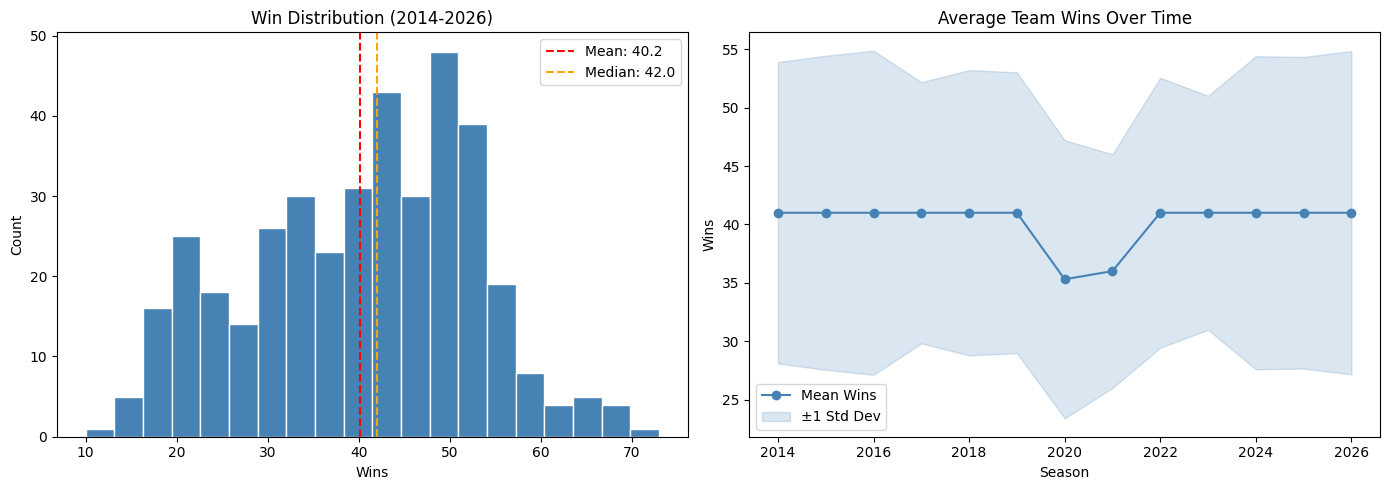

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(mega['W'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(mega['W'].mean(), color='red', linestyle='--', 
                label=f"Mean: {mega['W'].mean():.1f}")
axes[0].axvline(mega['W'].median(), color='orange', linestyle='--',
                label=f"Median: {mega['W'].median():.1f}")
axes[0].set_xlabel('Wins')
axes[0].set_ylabel('Count')
axes[0].set_title('Win Distribution (2014-2026)')
axes[0].legend()

# Wins over time
win_by_season = mega.groupby('Season')['W'].agg(['mean', 'std']).reset_index()
axes[1].plot(win_by_season['Season'], win_by_season['mean'], 
             color='steelblue', marker='o', label='Mean Wins')
axes[1].fill_between(win_by_season['Season'],
                     win_by_season['mean'] - win_by_season['std'],
                     win_by_season['mean'] + win_by_season['std'],
                     alpha=0.2, color='steelblue', label='±1 Std Dev')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Wins')
axes[1].set_title('Average Team Wins Over Time')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/win_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


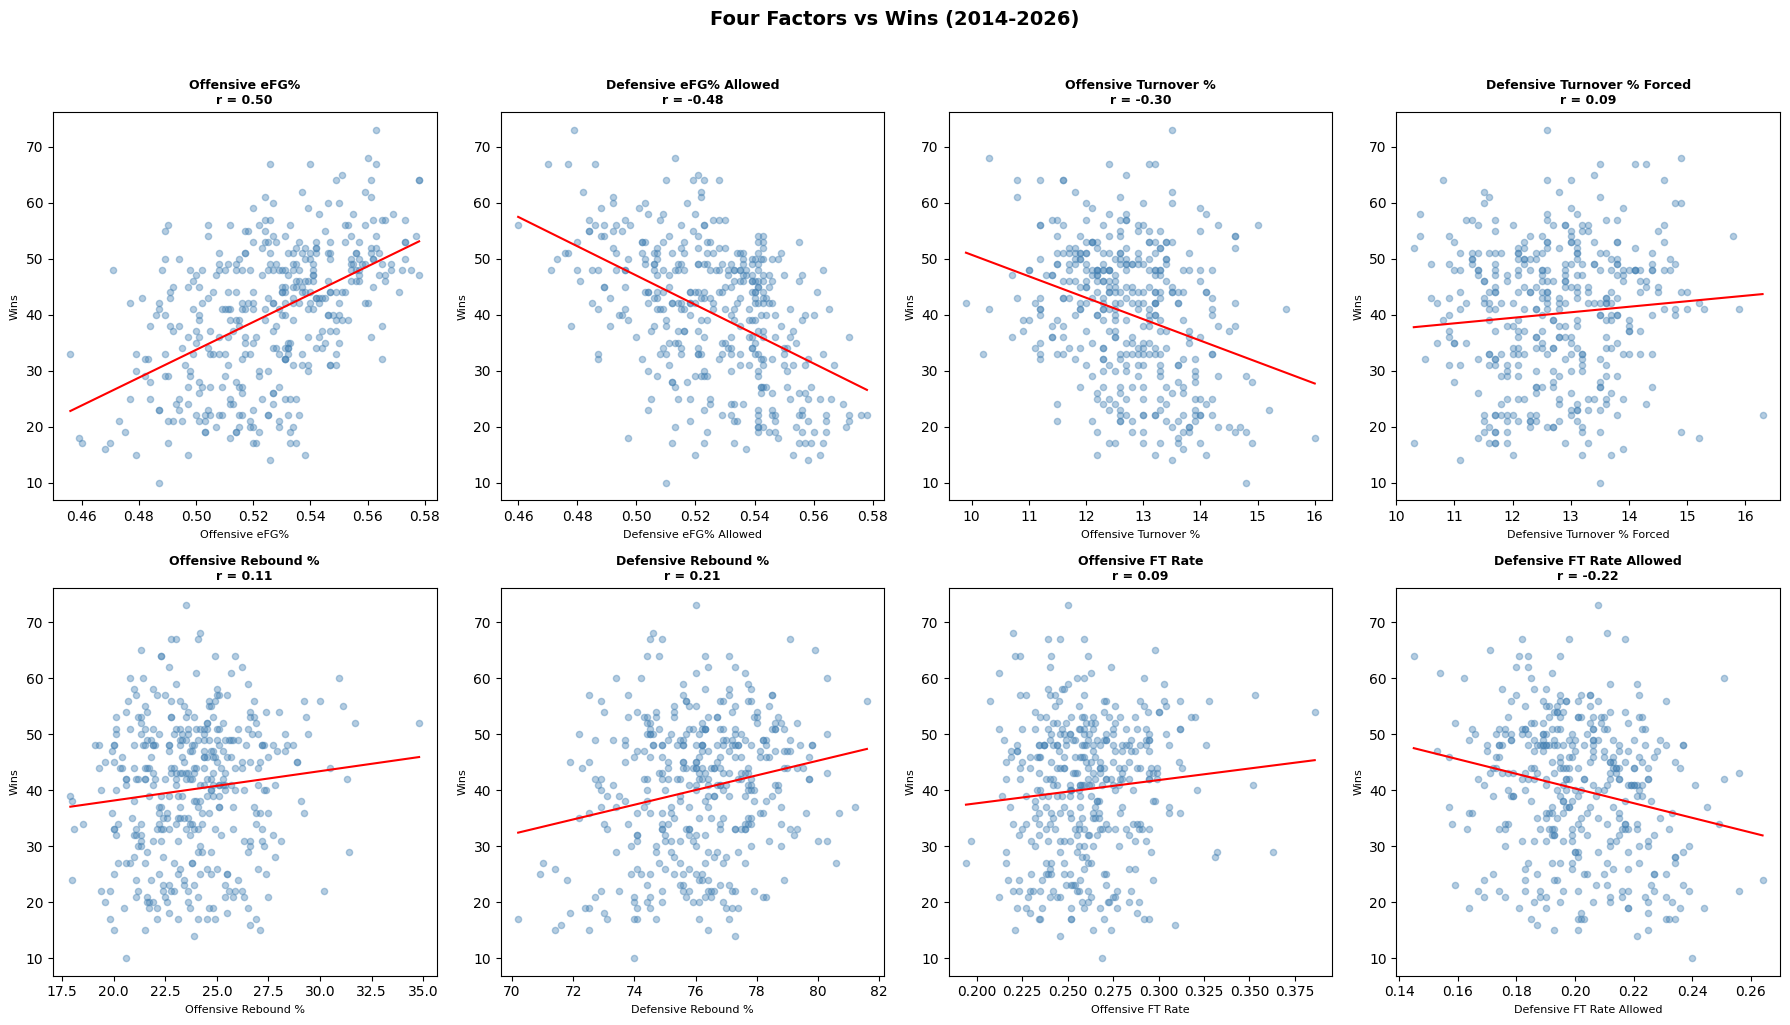

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

four_factors = {
    'OFF_eFG%': 'Offensive eFG%',
    'DEF_eFG%': 'Defensive eFG% Allowed',
    'OFF_TOV%': 'Offensive Turnover %',
    'DEF_TOV%': 'Defensive Turnover % Forced',
    'ORB%':     'Offensive Rebound %',
    'DRB%':     'Defensive Rebound %',
    'OFF_FT/FGA': 'Offensive FT Rate',
    'DEF_FT/FGA': 'Defensive FT Rate Allowed'
}

for ax, (col, label) in zip(axes.flatten(), four_factors.items()):
    ax.scatter(mega[col], mega['W'], alpha=0.4, color='steelblue', s=20)
    
    # Trend line
    z = np.polyfit(mega[col], mega['W'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(mega[col].min(), mega[col].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=1.5)
    
    # Correlation
    corr = mega[col].corr(mega['W'])
    ax.set_title(f'{label}\nr = {corr:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Wins', fontsize=8)

plt.suptitle('Four Factors vs Wins (2014-2026)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/four_factors_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

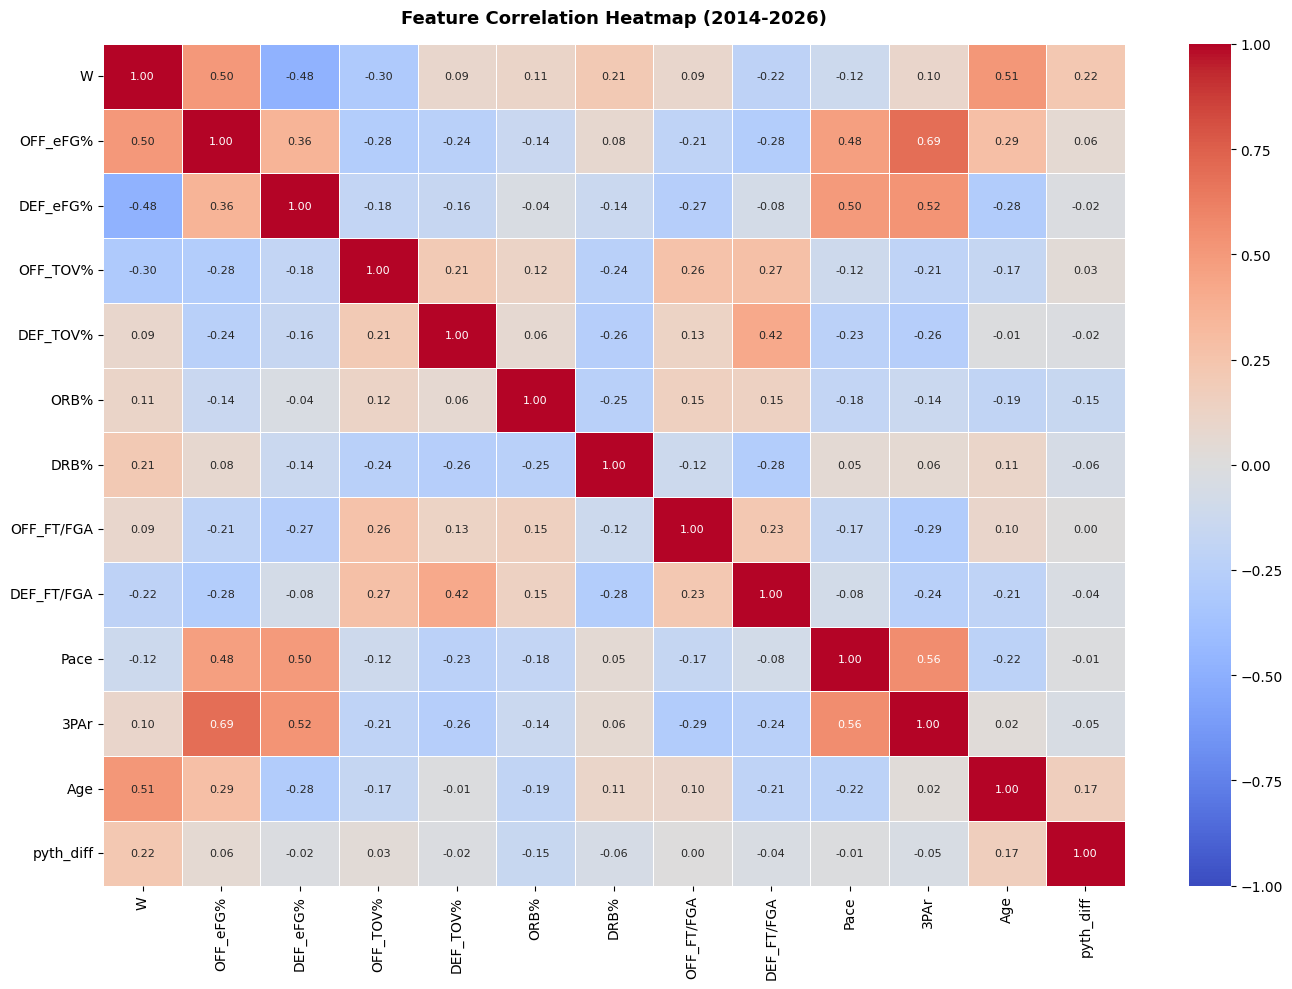

In [31]:
fig, ax = plt.subplots(figsize=(14, 10))

# Select features for heatmap
heatmap_cols = [
    'W',
    'OFF_eFG%', 'DEF_eFG%',
    'OFF_TOV%', 'DEF_TOV%',
    'ORB%', 'DRB%',
    'OFF_FT/FGA', 'DEF_FT/FGA',
    'Pace', '3PAr', 'Age',
    'pyth_diff'
]

corr_matrix = mega[heatmap_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={'size': 8},
    linewidths=0.5
)

ax.set_title('Feature Correlation Heatmap (2014-2026)', 
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Define features and target
features = [
    'G', 'Age', 'Pace', '3PAr',
    'OFF_eFG%', 'DEF_eFG%',
    'OFF_TOV%', 'DEF_TOV%',
    'ORB%', 'DRB%',
    'OFF_FT/FGA', 'DEF_FT/FGA',
    'pyth_diff'
]

target = 'PW'

# Chronological split
train = mega[mega['Season'] <= 2024]
test  = mega[mega['Season'].isin([2025, 2026])]

# Define X and y
X_train = train[features]
y_train = train[target]

X_test  = test[features]
y_test  = test[target]

# Confirm shapes
print("=== SPLIT SUMMARY ===")
print(f"Training:   {X_train.shape[0]} rows | Seasons 2014-2024")
print(f"Testing:    {X_test.shape[0]} rows  | Seasons 2025-2026")
print(f"Features:   {X_train.shape[1]}")
print(f"\nTraining target mean:  {y_train.mean():.1f} wins")
print(f"Testing target mean:   {y_test.mean():.1f} wins")
print(f"\nTraining seasons: {sorted(train['Season'].unique())}")
print(f"Testing seasons:  {sorted(test['Season'].unique())}")

=== SPLIT SUMMARY ===
Training:   330 rows | Seasons 2014-2024
Testing:    60 rows  | Seasons 2025-2026
Features:   13

Training target mean:  40.1 wins
Testing target mean:   41.1 wins

Training seasons: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Testing seasons:  [np.int64(2025), np.int64(2026)]


In [33]:
def build_models():
    ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000]))
    ])
    
    rf = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(
            n_estimators=500,
            max_depth=5,
            min_samples_leaf=3,
            random_state=42
        ))
    ])
    
    xgb = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(
            n_estimators=400,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbosity=0
        ))
    ])
    
    # Remove TimeSeriesSplit from stacking
    # use default cv=5 fold internally
    stack = StackingRegressor(
        estimators=[('ridge', ridge), ('rf', rf), ('xgb', xgb)],
        final_estimator=RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]),
        cv=5
    )
    
    return {'Ridge': ridge, 'Random Forest': rf, 
            'XGBoost': xgb, 'Stacked Ensemble': stack}


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    # Cross validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv,
        scoring='neg_mean_absolute_error'
    )
    
    # Fit and predict
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    # Playoff accuracy — did model correctly predict playoff teams
    # playoff threshold = top 10 teams per season (play-in included)
    results = test[['Team', 'Season', 'W']].copy()
    results['predicted'] = preds
    results['actual_playoff'] = results.groupby('Season')['W'].rank(
        ascending=False) <= 10
    results['pred_playoff'] = results.groupby('Season')['predicted'].rank(
        ascending=False) <= 10
    playoff_acc = (results['actual_playoff'] == results['pred_playoff']).mean()

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  CV MAE (train):     {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")
    print(f"  MAE  (holdout):     {mae:.2f} wins")
    print(f"  RMSE (holdout):     {rmse:.2f} wins")
    print(f"  R²   (holdout):     {r2:.3f}")
    print(f"  Playoff Accuracy:   {playoff_acc:.1%}")
    
    return {
        'name':         name,
        'model':        model,
        'predictions':  preds,
        'cv_mae':       -cv_scores.mean(),
        'cv_std':        cv_scores.std(),
        'mae':           mae,
        'rmse':          rmse,
        'r2':            r2,
        'playoff_acc':   playoff_acc
    }


def run_pipeline(X_train, y_train, X_test, y_test):
    models  = build_models()
    results = {}
    
    for name, model in models.items():
        results[name] = evaluate_model(
            name, model, 
            X_train, y_train, 
            X_test, y_test
        )
    
    # Summary table
    print(f"\n{'='*65}")
    print(f"  MODEL COMPARISON SUMMARY")
    print(f"{'='*65}")
    print(f"  {'Model':<20} {'CV MAE':>8} {'MAE':>8} {'RMSE':>8} "
          f"{'R²':>8} {'Playoff%':>10}")
    print(f"  {'-'*60}")
    for name, r in results.items():
        print(f"  {name:<20} {r['cv_mae']:>8.2f} {r['mae']:>8.2f} "
              f"{r['rmse']:>8.2f} {r['r2']:>8.3f} "
              f"{r['playoff_acc']:>10.1%}")
    
    return results



In [34]:
results = run_pipeline(X_train, y_train, X_test, y_test)


  Ridge
  CV MAE (train):     2.05 ± 1.15
  MAE  (holdout):     1.37 wins
  RMSE (holdout):     1.71 wins
  R²   (holdout):     0.984
  Playoff Accuracy:   90.0%

  Random Forest
  CV MAE (train):     5.80 ± 0.43
  MAE  (holdout):     6.54 wins
  RMSE (holdout):     7.76 wins
  R²   (holdout):     0.675
  Playoff Accuracy:   93.3%

  XGBoost
  CV MAE (train):     4.28 ± 0.69
  MAE  (holdout):     3.55 wins
  RMSE (holdout):     4.67 wins
  R²   (holdout):     0.882
  Playoff Accuracy:   93.3%

  Stacked Ensemble
  CV MAE (train):     2.05 ± 1.13
  MAE  (holdout):     1.35 wins
  RMSE (holdout):     1.68 wins
  R²   (holdout):     0.985
  Playoff Accuracy:   90.0%

  MODEL COMPARISON SUMMARY
  Model                  CV MAE      MAE     RMSE       R²   Playoff%
  ------------------------------------------------------------
  Ridge                    2.05     1.37     1.71    0.984      90.0%
  Random Forest            5.80     6.54     7.76    0.675      93.3%
  XGBoost                 

In [35]:
tscv = TimeSeriesSplit(n_splits=5)

print("=== FOLD BY FOLD ANALYSIS — RIDGE ===\n")

fold_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    
    # Split
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]
    
    # Get seasons in this fold
    train_seasons = train.iloc[train_idx]['Season'].unique()
    val_seasons   = train.iloc[val_idx]['Season'].unique()
    
    # Fit and predict
    ridge_fold = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000]))
    ])
    ridge_fold.fit(X_fold_train, y_fold_train)
    preds = ridge_fold.predict(X_fold_val)
    
    mae = mean_absolute_error(y_fold_val, preds)
    
    # Flag COVID seasons
    covid = '← COVID' if any(s in [2020, 2021] for s in val_seasons) else ''
    
    fold_results.append({
        'fold':           fold,
        'train_seasons':  f"{train_seasons.min()}-{train_seasons.max()}",
        'val_seasons':    sorted(val_seasons.tolist()),
        'mae':            mae,
        'covid':          covid
    })
    
    print(f"Fold {fold}:")
    print(f"  Train seasons:    {train_seasons.min()}-{train_seasons.max()}")
    print(f"  Validate seasons: {sorted(val_seasons.tolist())} {covid}")
    print(f"  MAE:              {mae:.2f} wins")
    print()

# Summary
maes        = [f['mae'] for f in fold_results]
covid_maes  = [f['mae'] for f in fold_results if f['covid']]
normal_maes = [f['mae'] for f in fold_results if not f['covid']]

print("=== SUMMARY ===")
print(f"Overall CV MAE:       {np.mean(maes):.2f} wins")
if covid_maes:
    print(f"COVID fold MAE:       {np.mean(covid_maes):.2f} wins")
if normal_maes:
    print(f"Non-COVID fold MAE:   {np.mean(normal_maes):.2f} wins")
print(f"Holdout MAE:          1.37 wins")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== FOLD BY FOLD ANALYSIS — RIDGE ===

Fold 1:
  Train seasons:    2014-2015
  Validate seasons: [2015, 2016, 2017] 
  MAE:              1.92 wins

Fold 2:
  Train seasons:    2014-2017
  Validate seasons: [2017, 2018, 2019] 
  MAE:              1.39 wins

Fold 3:
  Train seasons:    2014-2019
  Validate seasons: [2019, 2020, 2021] ← COVID
  MAE:              4.29 wins

Fold 4:
  Train seasons:    2014-2021
  Validate seasons: [2021, 2022, 2023] ← COVID
  MAE:              1.32 wins

Fold 5:
  Train seasons:    2014-2023
  Validate seasons: [2023, 2024] 
  MAE:              1.30 wins

=== SUMMARY ===
Overall CV MAE:       2.05 wins
COVID fold MAE:       2.81 wins
Non-COVID fold MAE:   1.54 wins
Holdout MAE:          1.37 wins


(11.659053431438306, 72.08417304197673)

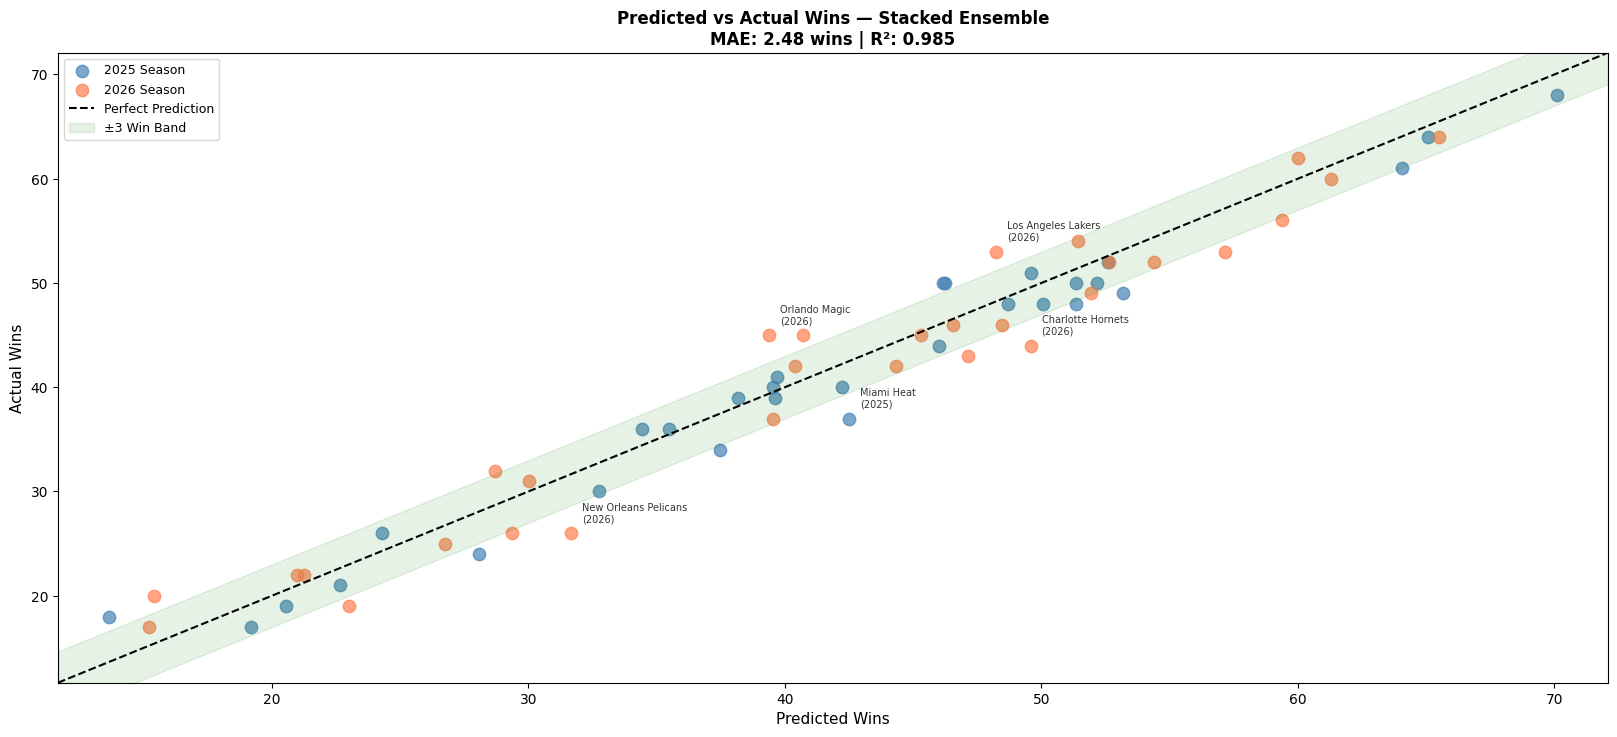

In [36]:
fig = plt.figure(figsize=(20, 18))

# Get predictions from best model (stacked ensemble)
test_results = test[['Team', 'Season', 'W']].copy()
test_results['Predicted'] = results['Stacked Ensemble']['predictions']
test_results['Error'] = test_results['Predicted'] - test_results['W']
test_results['Abs_Error'] = test_results['Error'].abs()

# ============================================================
# CHART 1 — Predicted vs Actual Scatter
# ============================================================
ax1 = fig.add_subplot(2, 2, (1, 2))

# Color by season
colors_season = {2025: 'steelblue', 2026: 'coral'}
for season in [2025, 2026]:
    mask = test_results['Season'] == season
    ax1.scatter(
        test_results[mask]['Predicted'],
        test_results[mask]['W'],
        color=colors_season[season],
        alpha=0.7, s=80,
        label=f'{season} Season'
    )

# Perfect prediction line
min_val = min(test_results['W'].min(), test_results['Predicted'].min()) - 2
max_val = max(test_results['W'].max(), test_results['Predicted'].max()) + 2
ax1.plot([min_val, max_val], [min_val, max_val],
         'k--', linewidth=1.5, label='Perfect Prediction')

# Confidence band ±3 wins
ax1.fill_between([min_val, max_val],
                 [min_val-3, max_val-3],
                 [min_val+3, max_val+3],
                 alpha=0.1, color='green', label='±3 Win Band')

# Label biggest outliers
outliers = test_results.nlargest(5, 'Abs_Error')
for _, row in outliers.iterrows():
    ax1.annotate(
        f"{row['Team']}\n({row['Season']})",
        xy=(row['Predicted'], row['W']),
        xytext=(8, 8), textcoords='offset points',
        fontsize=7, alpha=0.8
    )

ax1.set_xlabel('Predicted Wins', fontsize=11)
ax1.set_ylabel('Actual Wins', fontsize=11)
ax1.set_title('Predicted vs Actual Wins — Stacked Ensemble\n'
              f'MAE: {test_results["Abs_Error"].mean():.2f} wins | '
              f'R²: {results["Stacked Ensemble"]["r2"]:.3f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_xlim(min_val, max_val)
ax1.set_ylim(min_val, max_val)





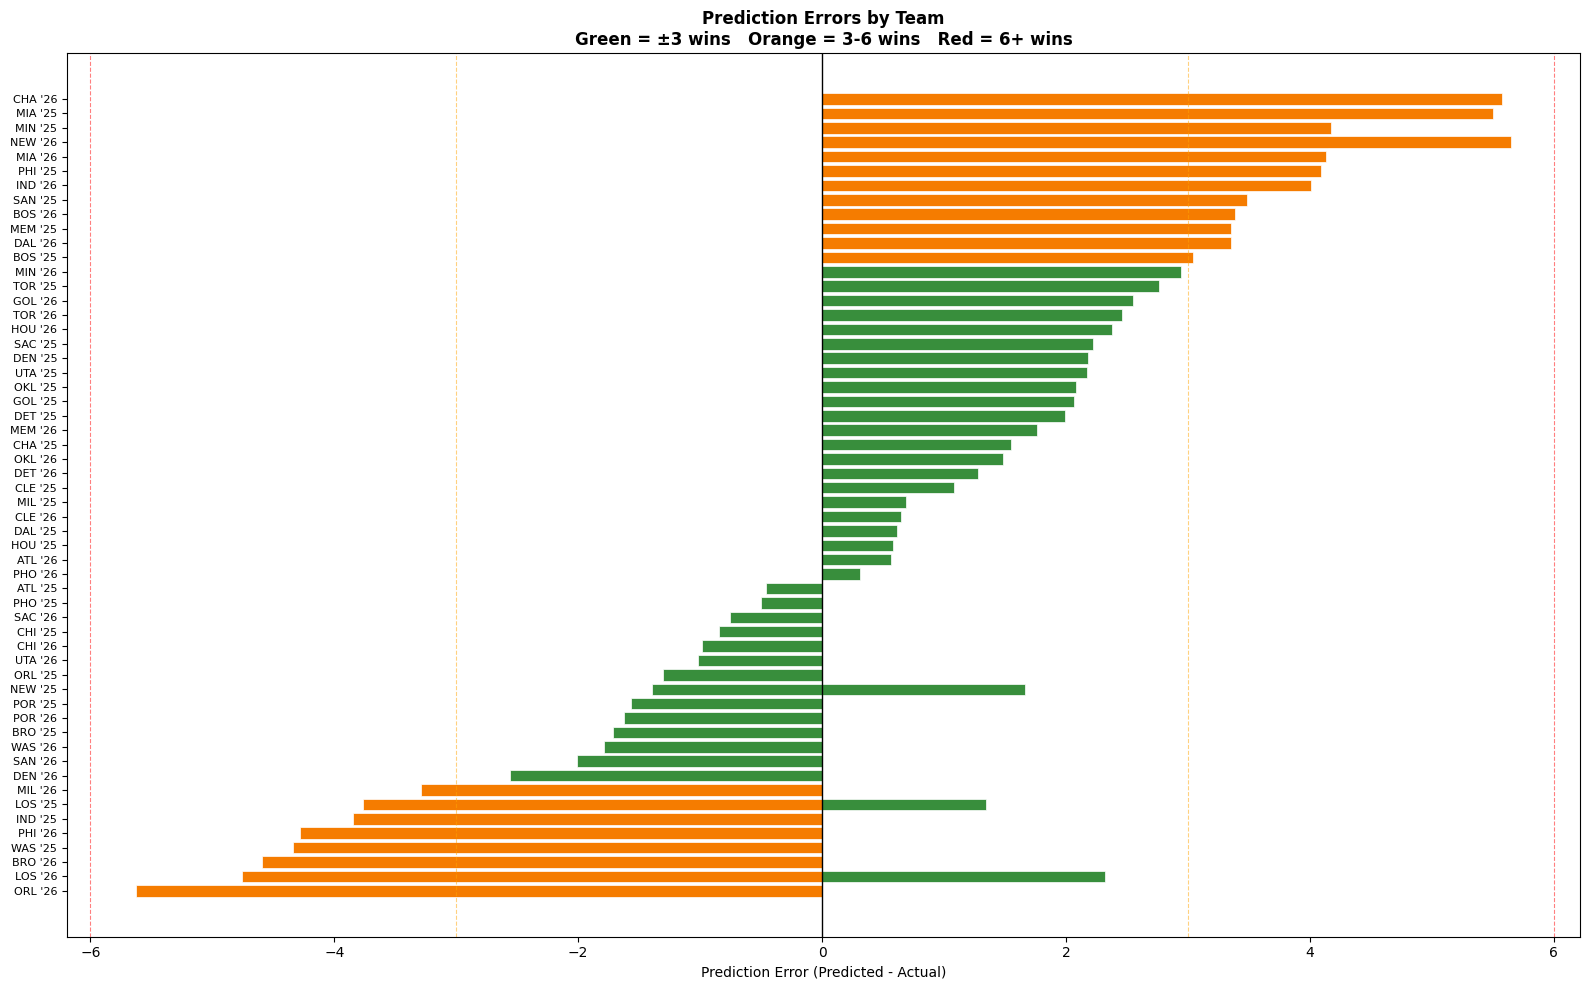

In [37]:
# ============================================================
# CHART 2 — Residual Bar Chart By Team
# ============================================================
fig2, ax2 = plt.subplots(figsize=(16, 10))

# Sort by error
sorted_results = test_results.sort_values('Error')
sorted_results['Label'] = (
    sorted_results['Team'].str[:3].str.upper() + 
    " '" + sorted_results['Season'].astype(str).str[-2:]
)

# Color by error magnitude
bar_colors = [
    '#d32f2f' if abs(e) > 6 else
    '#f57c00' if abs(e) > 3 else
    '#388e3c'
    for e in sorted_results['Error']
]

ax2.barh(sorted_results['Label'], sorted_results['Error'],
         color=bar_colors, edgecolor='white', linewidth=0.5)

ax2.axvline(x=0,  color='black',  linewidth=1.0)
ax2.axvline(x=3,  color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(x=-3, color='orange', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(x=6,  color='red',    linestyle='--', linewidth=0.8, alpha=0.5)
ax2.axvline(x=-6, color='red',    linestyle='--', linewidth=0.8, alpha=0.5)

ax2.set_xlabel('Prediction Error (Predicted - Actual)', fontsize=10)
ax2.set_title(
    'Prediction Errors by Team\n'
    'Green = ±3 wins   Orange = 3-6 wins   Red = 6+ wins',
    fontsize=12, fontweight='bold'
)
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('data/residual_chart.png', dpi=150, bbox_inches='tight')
plt.show()

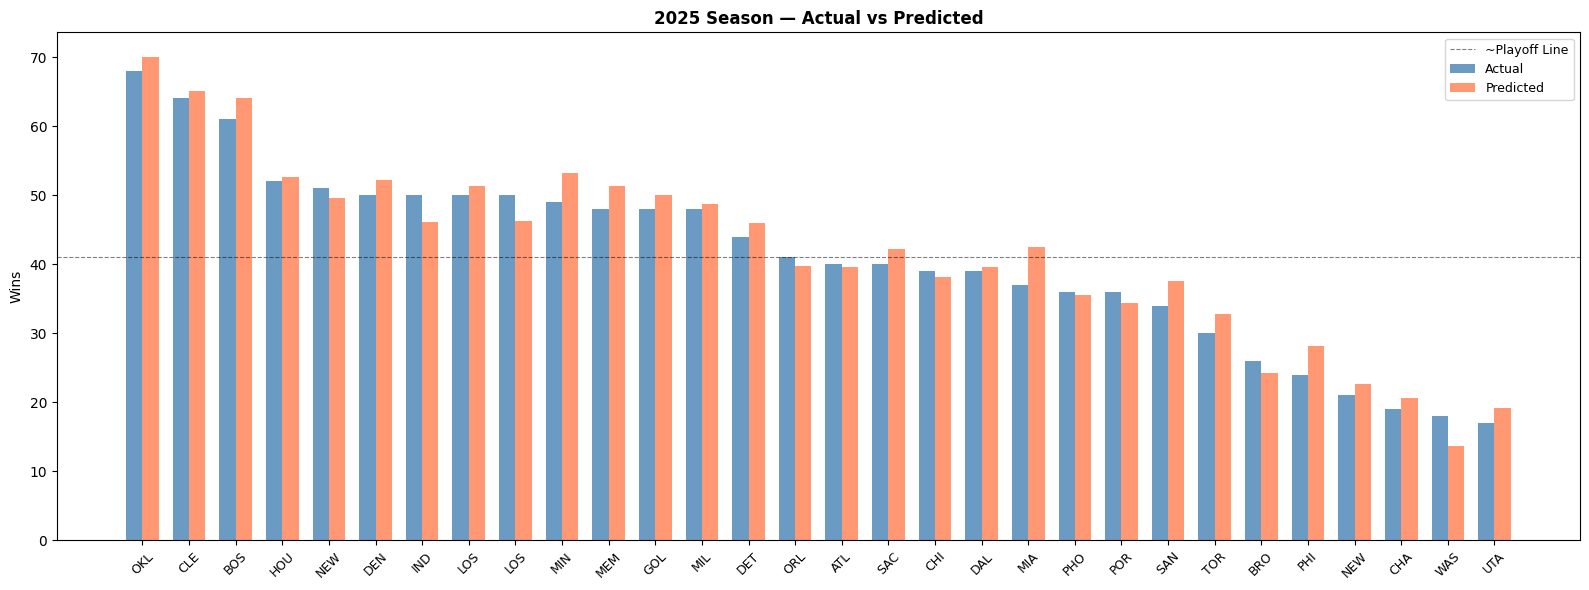

In [38]:
# ============================================================
# CHART 3 — 2025 and 2026 Side by Side
# ============================================================
fig3, ax3 = plt.subplots(figsize=(16, 6))

s2025 = test_results[test_results['Season'] == 2025].sort_values(
    'W', ascending=False
)
x = np.arange(len(s2025))
width = 0.35

ax3.bar(x - width/2, s2025['W'],         width,
        label='Actual',    color='steelblue', alpha=0.8)
ax3.bar(x + width/2, s2025['Predicted'], width,
        label='Predicted', color='coral',     alpha=0.8)

ax3.set_xticks(x)
ax3.set_xticklabels(
    s2025['Team'].str[:3].str.upper(),
    rotation=45, fontsize=9
)
ax3.axhline(y=41, color='black', linestyle='--',
            linewidth=0.8, alpha=0.5, label='~Playoff Line')
ax3.set_ylabel('Wins', fontsize=10)
ax3.set_title('2025 Season — Actual vs Predicted',
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/season_2025.png', dpi=150, bbox_inches='tight')
plt.show()

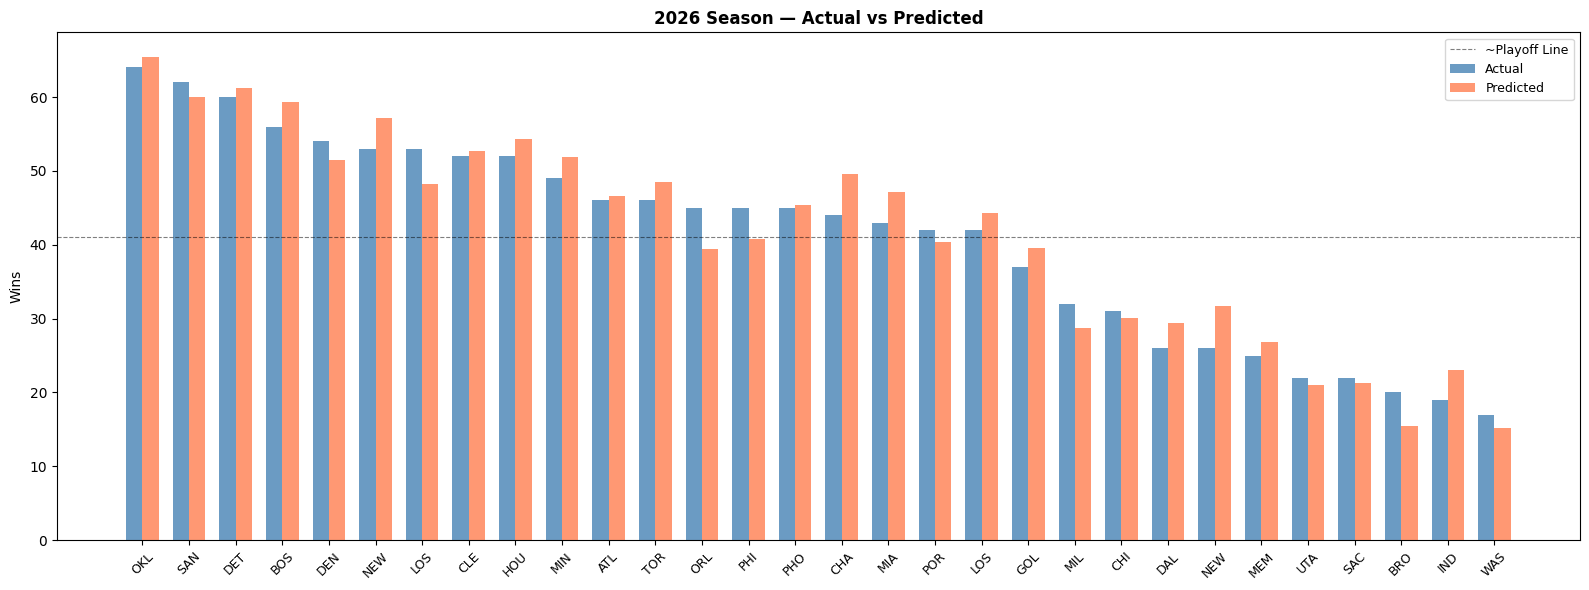

In [39]:
# ============================================================
# CHART 4 — 2026 Season Actual vs Predicted (bottom right)
# ============================================================
fig4, ax4 = plt.subplots(figsize=(16, 6))

s2026 = test_results[test_results['Season'] == 2026].sort_values(
    'W', ascending=False
)
x = np.arange(len(s2026))
width = 0.35

ax4.bar(x - width/2, s2026['W'],         width,
        label='Actual',    color='steelblue', alpha=0.8)
ax4.bar(x + width/2, s2026['Predicted'], width,
        label='Predicted', color='coral',     alpha=0.8)

ax4.set_xticks(x)
ax4.set_xticklabels(
    s2026['Team'].str[:3].str.upper(),
    rotation=45, fontsize=9
)
ax4.axhline(y=41, color='black', linestyle='--',
            linewidth=0.8, alpha=0.5, label='~Playoff Line')
ax4.set_ylabel('Wins', fontsize=10)
ax4.set_title('2026 Season — Actual vs Predicted',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/season_2026.png', dpi=150, bbox_inches='tight')
plt.show()

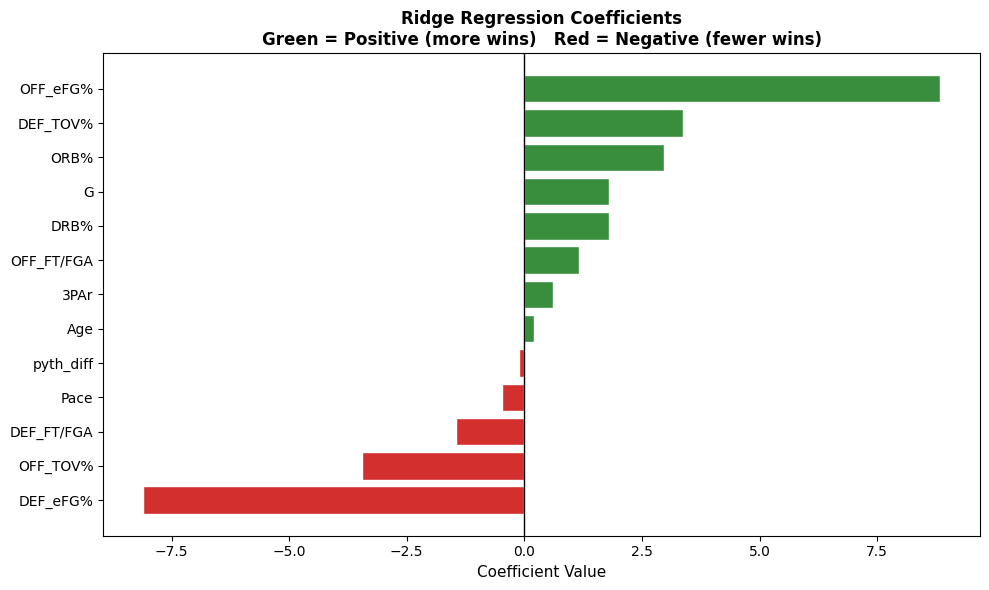

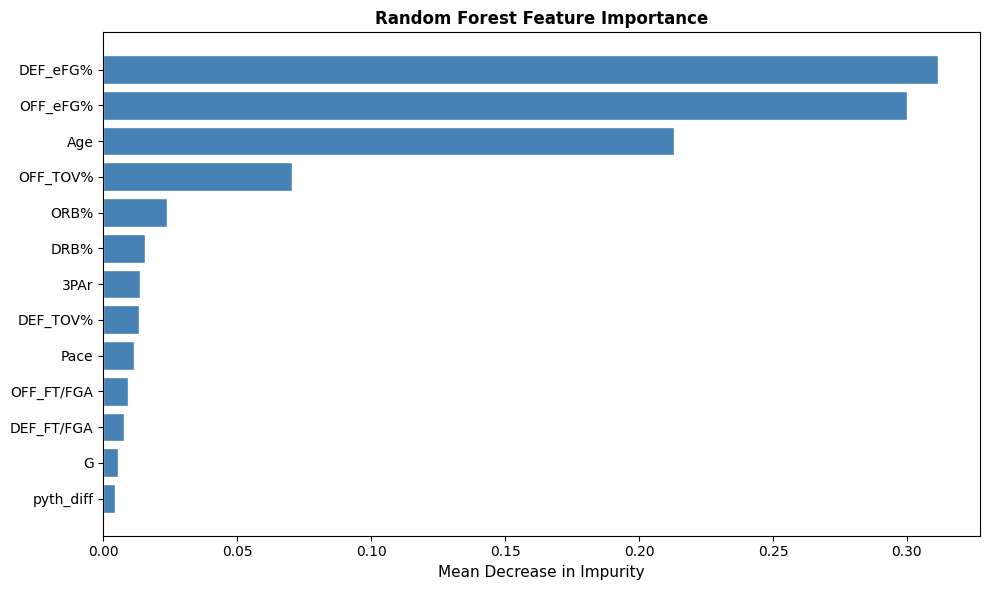

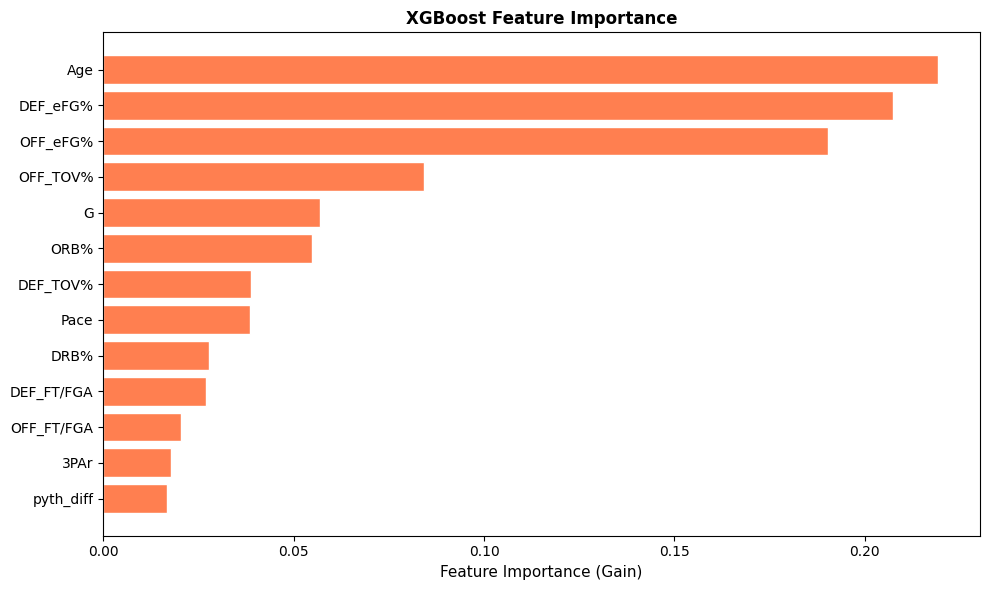

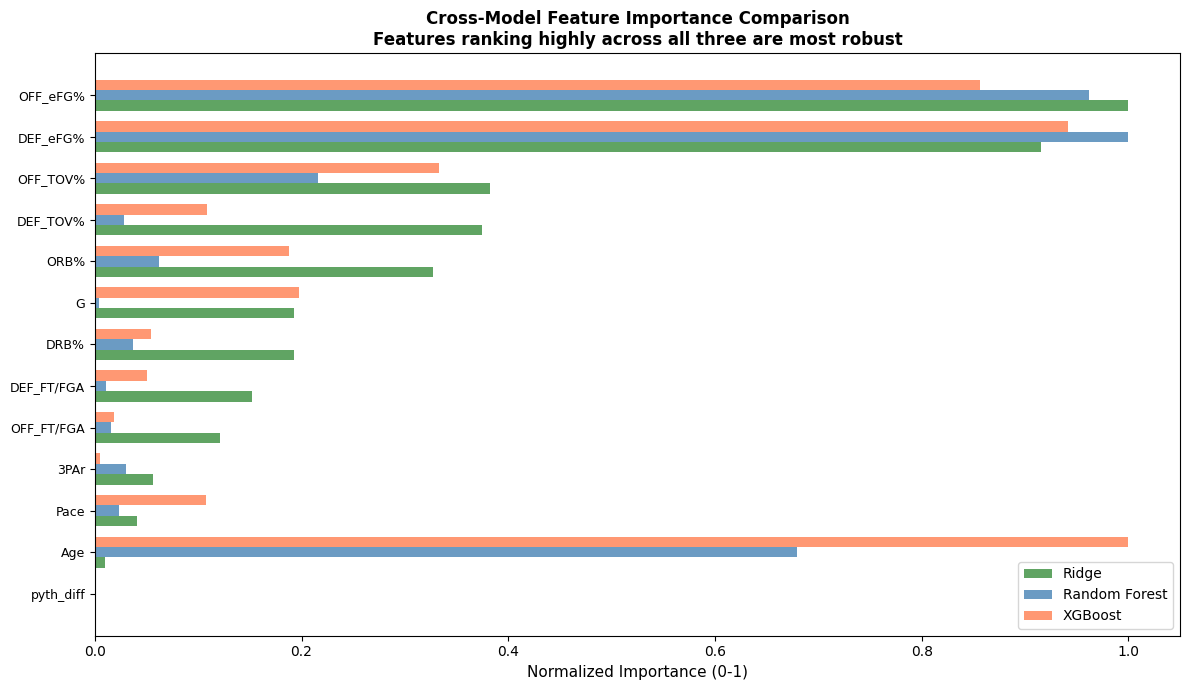

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# 1. RIDGE COEFFICIENTS
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

ridge_model  = results['Ridge']['model']
ridge_coefs  = ridge_model.named_steps['model'].coef_
ridge_importance = pd.Series(ridge_coefs, index=features).sort_values()

colors = ['#d32f2f' if v < 0 else '#388e3c' for v in ridge_importance]

ax1.barh(ridge_importance.index, ridge_importance.values,
         color=colors, edgecolor='white')
ax1.axvline(x=0, color='black', linewidth=1)
ax1.set_xlabel('Coefficient Value', fontsize=11)
ax1.set_title('Ridge Regression Coefficients\n'
              'Green = Positive (more wins)   '
              'Red = Negative (fewer wins)',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/ridge_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 2. RANDOM FOREST IMPORTANCE
# ============================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

rf_model      = results['Random Forest']['model']
rf_importance = pd.Series(
    rf_model.named_steps['model'].feature_importances_,
    index=features
).sort_values()

ax2.barh(rf_importance.index, rf_importance.values,
         color='steelblue', edgecolor='white')
ax2.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax2.set_title('Random Forest Feature Importance',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. XGBOOST IMPORTANCE
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))

xgb_model      = results['XGBoost']['model']
xgb_importance = pd.Series(
    xgb_model.named_steps['model'].feature_importances_,
    index=features
).sort_values()

ax3.barh(xgb_importance.index, xgb_importance.values,
         color='coral', edgecolor='white')
ax3.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax3.set_title('XGBoost Feature Importance',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('data/xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. CROSS MODEL COMPARISON
# ============================================================
fig4, ax4 = plt.subplots(figsize=(12, 7))

def normalize(s):
    s = s.abs()
    return (s - s.min()) / (s.max() - s.min())

comparison = pd.DataFrame({
    'Ridge':         normalize(ridge_importance),
    'Random Forest': normalize(rf_importance),
    'XGBoost':       normalize(xgb_importance)
}).sort_values('Ridge')

x     = np.arange(len(comparison))
width = 0.25

ax4.barh(x - width, comparison['Ridge'],
         width, label='Ridge',         color='#388e3c', alpha=0.8)
ax4.barh(x,         comparison['Random Forest'],
         width, label='Random Forest', color='steelblue', alpha=0.8)
ax4.barh(x + width, comparison['XGBoost'],
         width, label='XGBoost',       color='coral', alpha=0.8)

ax4.set_yticks(x)
ax4.set_yticklabels(comparison.index, fontsize=9)
ax4.set_xlabel('Normalized Importance (0-1)', fontsize=11)
ax4.set_title('Cross-Model Feature Importance Comparison\n'
              'Features ranking highly across all three are most robust',
              fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)

plt.tight_layout()
plt.savefig('data/cross_model_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ============================================================
# 2026-27 SEASON BLIND PREDICTION
# ============================================================

features = [
    'G', 'Age', 'Pace', '3PAr',
    'OFF_eFG%', 'DEF_eFG%',
    'OFF_TOV%', 'DEF_TOV%',
    'ORB%', 'DRB%',
    'OFF_FT/FGA', 'DEF_FT/FGA',
    'pyth_diff'
]

def project_next_season(mega, features, span=3, regression_weight=0.15):
    
    # Step 1 — EWM projection
    # Sort chronologically within each team
    # Apply EWM and take the last value as projection
    ewm_proj = (mega.sort_values('Season')
                    .groupby('Team')[features]
                    .apply(lambda x: x.ewm(span=span)
                                      .mean()
                                      .iloc[-1])
                    .reset_index())
    
    # Step 2 — Regression to mean adjustment
    # Pull extreme projections 15% toward league average
    league_avg = mega[features].mean()
    
    for feat in features:
        ewm_proj[feat] = (ewm_proj[feat] * (1 - regression_weight) + 
                          league_avg[feat] * regression_weight)
    
    ewm_proj['Season'] = 2027
    
    return ewm_proj


def predict_with_intervals(model, X_future, X_train, y_train, 
                           n_bootstrap=1000):
    
    # Point prediction
    point_pred = model.predict(X_future)
    
    # Bootstrap confidence intervals
    bootstrap_preds = []
    for _ in range(n_bootstrap):
        X_boot, y_boot = resample(X_train, y_train, random_state=None)
        model_boot = clone(model)
        model_boot.fit(X_boot, y_boot)
        bootstrap_preds.append(model_boot.predict(X_future))
    
    bootstrap_preds = np.array(bootstrap_preds)
    lower = np.percentile(bootstrap_preds, 10, axis=0)
    upper = np.percentile(bootstrap_preds, 90, axis=0)
    
    return point_pred, lower, upper



In [42]:


# Generate 2026-27 inputs
future_inputs = project_next_season(mega, features)
X_future = future_inputs[features]

# ============================================================
# POINT PREDICTIONS — use stacked ensemble, instant
# ============================================================
best_model = results['Stacked Ensemble']['model']
point_pred = best_model.predict(X_future)

# ============================================================
# CONFIDENCE INTERVALS — use Ridge only, much faster
# 200 bootstraps is sufficient for dataset size
# ============================================================
ridge_model = results['Ridge']['model']
n_bootstrap = 200

bootstrap_preds = []
for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)
    ridge_boot = clone(ridge_model)
    ridge_boot.fit(X_boot, y_boot)
    bootstrap_preds.append(ridge_boot.predict(X_future))

bootstrap_preds = np.array(bootstrap_preds)
lower = np.percentile(bootstrap_preds, 10, axis=0)
upper = np.percentile(bootstrap_preds, 90, axis=0)

# ============================================================
# BUILD RESULTS
# ============================================================
predictions_2027 = pd.DataFrame({
    'Team':      future_inputs['Team'],
    'Season':    2027,
    'Predicted': np.round(point_pred).astype(int),
    'Lower':     np.round(lower).astype(int),
    'Upper':     np.round(upper).astype(int)
}).sort_values('Predicted', ascending=False).reset_index(drop=True)

predictions_2027['Range'] = (predictions_2027['Lower'].astype(str) + 
                              ' - ' + 
                              predictions_2027['Upper'].astype(str))

# Print results
print("=" * 60)
print("  2026-27 NBA WIN PREDICTIONS")
print("  Point: Stacked Ensemble")
print("  CI: Ridge Bootstrap (n=200) | 80% Confidence")
print("  Method: EWM (span=3) + 15% Regression to Mean")
print("=" * 60)
print(f"{'Rank':<5} {'Team':<25} {'Predicted':>9} {'80% CI':>15}")
print("-" * 60)

for i, row in predictions_2027.iterrows():
    print(f"{i+1:<5} {row['Team']:<25} "
          f"{row['Predicted']:>9} {row['Range']:>15}")

print("=" * 60)
print(f"League avg predicted: {predictions_2027['Predicted'].mean():.1f} wins")


  2026-27 NBA WIN PREDICTIONS
  Point: Stacked Ensemble
  CI: Ridge Bootstrap (n=200) | 80% Confidence
  Method: EWM (span=3) + 15% Regression to Mean
Rank  Team                      Predicted          80% CI
------------------------------------------------------------
1     Boston Celtics                   58         57 - 58
2     Oklahoma City Thunder            58         58 - 59
3     Cleveland Cavaliers              52         52 - 52
4     New York Knicks                  51         51 - 51
5     Denver Nuggets                   50         49 - 50
6     Minnesota Timberwolves           50         49 - 50
7     Houston Rockets                  48         47 - 48
8     Detroit Pistons                  47         46 - 47
9     Los Angeles Clippers             46         45 - 46
10    Los Angeles Lakers               45         45 - 46
11    San Antonio Spurs                45         45 - 46
12    Miami Heat                       44         44 - 45
13    Phoenix Suns                

In [43]:
predictions_2027.to_csv('data/predictions_2027.csv', index=False)
print("\nSaved: data/predictions_2027.csv")


Saved: data/predictions_2027.csv


In [ ]:
# front load on EFG%
# Dive in on why the models are diffreent and how they with different features to be abe to comfortbly explain
# suprises and anomalies/ reasearch based.